# Sigmoid Function -- From Scratch

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import LabelEncoder

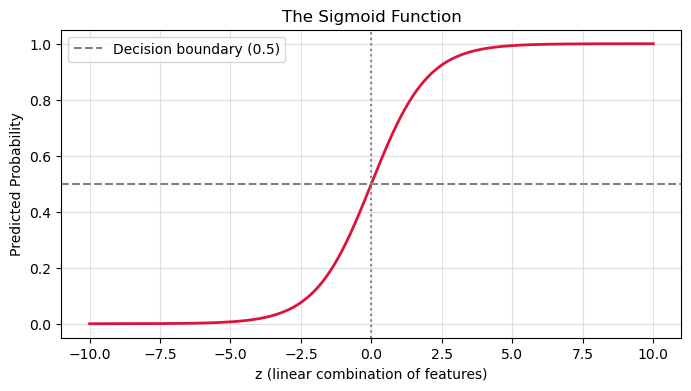

In [2]:
# The sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)

# Visualize 
plt.figure(figsize = (8, 4))
plt.plot(z, sigmoid(z), color = 'crimson', linewidth = 2)
plt.axhline(0.5, color = 'gray', linestyle = '--', label = 'Decision boundary (0.5)')
plt.axvline(0, color = 'gray', linestyle = ':')
plt.title("The Sigmoid Function")
plt.xlabel("z (linear combination of features)")
plt.ylabel("Predicted Probability")
plt.legend()
plt.grid(True, alpha = 0.4)


plt.show()

# Way 2: Full Model On Real Project Data

Features shape: (395, 32)
Target distribution:
completed
1    357
0     38
Name: count, dtype: int64

==================== MODEL PERFORMANCE ====================
Accuracy Score: 0.9620
Precision Score: 0.9595
Recall Score: 1.0000
F1 Score: 0.9793
ROC- AUC Score: 0.8125


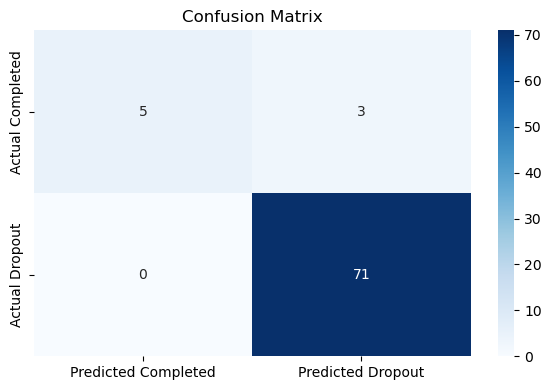


               precision    recall  f1-score   support

   Completed       1.00      0.62      0.77         8
     Dropout       0.96      1.00      0.98        71

    accuracy                           0.96        79
   macro avg       0.98      0.81      0.87        79
weighted avg       0.96      0.96      0.96        79



In [18]:
# Load Dataset
df = pd.read_csv('student_classification.csv')

# Encode Categorical Dataset
# Logistic regression needs numbers -- not text categories
df_encoded = df.copy()
categorical_cols = df_encoded.select_dtypes(include = 'object').columns


le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Features and Target
# Drop G3 -- it directly reveals the answer (data leakage)
X = df_encoded.drop(columns = ['completed', 'G3'])
y = df_encoded['completed']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y) # startify = y ensures both splits have same dropout ratio

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test) # Class labels: 0 or 1
y_pred_proba = model.predict_proba(X_test)[:, 1] # Dropout probability

# Evaluation
print("="*20 + " MODEL PERFORMANCE " + "=" * 20)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score: {precision_score(y_test, y_pred):.4f}")
print(f"Recall Score: {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC- AUC Score: {roc_auc_score(y_test, y_pred):.4f}")
print("="*60)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (6, 4))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = ['Predicted Completed', 'Predicted Dropout'], yticklabels = ['Actual Completed', 'Actual Dropout'])
plt.title("Confusion Matrix")
plt.tight_layout()


plt.show()

# Full Classification Report
print("\n", classification_report(y_test, y_pred, target_names = ['Completed', 'Dropout']))

# Which Features Your Model 

In [17]:
# Which features does your model consider most important?
feature_importance = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("Top 5 features pushing TOWARD dropout:")
print(feature_importance.tail(5).to_string())

print("\nTop 5 features pushing AWAY from dropout:")
print(feature_importance.head(5).to_string())

Top 5 features pushing TOWARD dropout:
       Feature  Coefficient
13   studytime    -0.448125
18  activities    -0.494619
14    failures    -0.495858
26        Dalc    -0.515052
2          age    -1.108051

Top 5 features pushing AWAY from dropout:
      Feature  Coefficient
29   absences     1.767018
31         G2     1.186278
28     health     0.730713
0      school     0.475063
15  schoolsup     0.449621


Average absences:
completed
0    0.00
1    6.32
Name: absences, dtype: float64

Average studytime:
completed
0    1.97
1    2.04
Name: studytime, dtype: float64


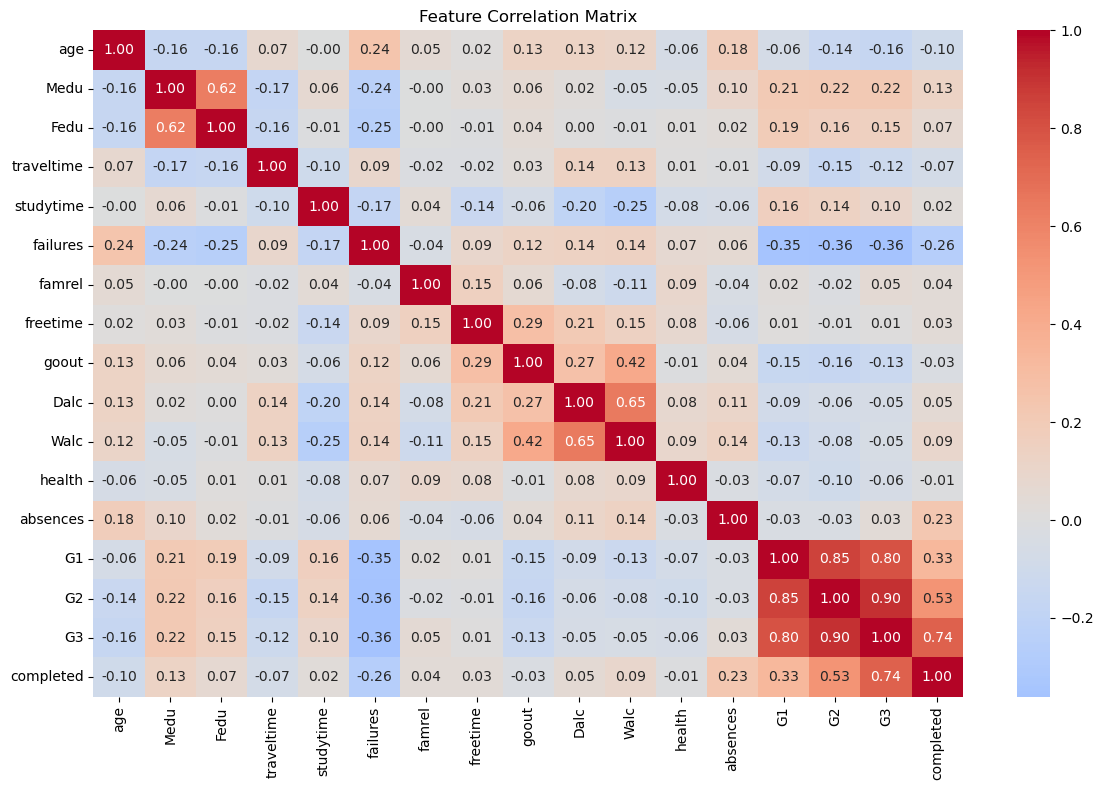

In [20]:
# Compare absences between dropout vs completed students
print("Average absences:")
print(df.groupby('completed')['absences'].mean().round(2))

# Compare studytime between dropout vs completed students
print()
print("Average studytime:")
print(df.groupby('completed')['studytime'].mean().round(2))

# Full correlation check
numeric_cols = df.select_dtypes(include = np.number).columns

plt.figure(figsize = (12, 8))
sns.heatmap(df[numeric_cols].corr(), annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# 📘 Session 03 — Logistic Regression
### *Data Science & Machine Learning — Personal Study Notes*
---
> **"Model metrics tell you how well the model performs. Coefficient analysis tells you why — but only if you question it critically. Domain knowledge is the filter that separates real insights from mathematical artifacts."**

---

## 📌 Table of Contents
1. [What Is Logistic Regression?](#1-what-is-logistic-regression)
2. [The Sigmoid Function](#2-the-sigmoid-function)
3. [The Decision Boundary](#3-the-decision-boundary)
4. [Log Loss — The Loss Function](#4-log-loss--the-loss-function)
5. [Gradient Descent — First Appearance](#5-gradient-descent--first-appearance)
6. [Evaluation Metrics](#6-evaluation-metrics)
7. [LabelEncoder](#7-labelencoder)
8. [fit vs transform vs fit_transform](#8-fit-vs-transform-vs-fit_transform)
9. [stratify — Why It Matters](#9-stratify--why-it-matters)
10. [predict vs predict_proba](#10-predict-vs-predict_proba)
11. [ROC and ROC-AUC](#11-roc-and-roc-auc)
12. [Failure Cases](#12-failure-cases)
13. [Project — Student Dropout Model](#13-project--student-dropout-model)
14. [Summary Cheatsheet](#15-summary-cheatsheet)

---

## 1. What Is Logistic Regression?

### The Problem It Solves

Sessions 1 and 2 predicted **numbers** — a student's exact exam score. That is regression.

Now ask a different question:
> *"Will this student drop out — yes or no?"*

The answer is not a number. It is a **category.** This is called a **classification problem** — and linear regression cannot solve it properly.

### Why Linear Regression Breaks For Classification

```
Using linear regression to predict dropout:
  Student A → prediction:  0.3   (what does 0.3 mean? Not a category)
  Student B → prediction:  1.4   (impossible — no such class)
  Student C → prediction: -0.2   (negative probability? Nonsensical)
```

You need a model that always outputs a value **between 0 and 1** — interpretable as a probability:
> *"This student has a 78% chance of dropping out."*

That is exactly what **Logistic Regression** does.

---

## 2. The Sigmoid Function

### What It Does

The Sigmoid function takes **any number** from −∞ to +∞ and squashes it into a value **between 0 and 1:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Where $z$ is the familiar linear combination:
$$z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

So the full logistic regression equation:
$$\hat{p} = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n)}}$$

Where $\hat{p}$ = predicted probability — always between 0 and 1.

### The S-Curve Behavior

| z value | Sigmoid output | Meaning |
|---|---|---|
| Very large positive (+10) | → close to 1.0 | Almost certain — yes |
| 0 | → exactly 0.5 | Perfectly uncertain |
| Very large negative (−10) | → close to 0.0 | Almost certain — no |

> ✅ The Sigmoid squashes any number into 0–1 range — this is what makes probability output possible.

---

## 3. The Decision Boundary

Once you have a probability, you need a rule to make a final decision:

$$\hat{y} = \begin{cases} 1 & \text{if } \hat{p} \geq 0.5 \\ 0 & \text{if } \hat{p} < 0.5 \end{cases}$$

### The Threshold Is A Business Decision — Not A Math Decision

The default threshold is 0.5 — but it is not sacred.

| Threshold | Effect | When To Use |
|---|---|---|
| **0.5** (default) | Balanced treatment of both errors | General use |
| **0.3** (lower) | Catches more real dropouts — more false alarms | When missing a case is costly |
| **0.7** (higher) | Very confident before flagging — misses more | When false alarms are costly |

> In our project — missing a real dropout is far more costly than a false alarm. We may lower the threshold to 0.3 to maximize recall.

---

## 4. Log Loss — The Loss Function

### Why Not MSE?

MSE creates a **non-convex** problem for logistic regression — full of local minima where the optimizer gets stuck. Instead we use **Log Loss** (Binary Cross-Entropy):

$$\text{Log Loss} = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

### How It Works

| When actual $y = 1$ | When actual $y = 0$ |
|---|---|
| Uses $\log(\hat{p})$ | Uses $\log(1 - \hat{p})$ |
| Penalizes heavily if $\hat{p}$ close to 0 | Penalizes heavily if $\hat{p}$ close to 1 |
| Rewards if $\hat{p}$ close to 1 | Rewards if $\hat{p}$ close to 0 |

> The closer your predicted probability is to the wrong answer — the heavier the penalty. Log Loss is a smarter teacher than MSE for classification.

---

## 5. Gradient Descent — First Appearance

Unlike linear regression which had a clean OLS closed-form solution, logistic regression has **no closed-form solution.** Parameters are learned iteratively:

```
Start with random θ values
         ↓
Calculate predictions using current θ
         ↓
Calculate Log Loss — how wrong are we?
         ↓
Calculate gradient — which direction reduces loss?
         ↓
Update θ slightly in that direction
         ↓
Repeat until loss stops improving
```

> ⚠️ **This is your first encounter with Gradient Descent** — the engine that powers not just logistic regression but every neural network ever built. We will go much deeper when we reach deep learning. For now understand: it is an iterative process of making small improvements until the model converges.

---

## 6. Evaluation Metrics

### Why R² Is Gone

R² measured how well you explained continuous variance. Categories have no variance to explain. You need completely different metrics.

---

### The Confusion Matrix — Foundation of Everything

$$\begin{bmatrix} \text{True Negative (TN)} & \text{False Positive (FP)} \\ \text{False Negative (FN)} & \text{True Positive (TP)} \end{bmatrix}$$

| Term | Plain English | In Our Project |
|---|---|---|
| **True Positive (TP)** | Predicted dropout — actually dropped out | Caught a real at-risk student ✅ |
| **True Negative (TN)** | Predicted completed — actually completed | Correctly cleared a safe student ✅ |
| **False Positive (FP)** | Predicted dropout — actually completed | Unnecessary intervention ⚠️ |
| **False Negative (FN)** | Predicted completed — actually dropped out | **Missed a real dropout** ❌ |

> In our project — **False Negatives are the most dangerous outcome.** A student who needed help got none.

---

### The Four Key Metrics

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall} = \frac{TP}{TP + FN}$$

$$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

| Metric | Question It Answers | When It Matters Most |
|---|---|---|
| **Accuracy** | Overall — how often is the model correct? | Balanced datasets only |
| **Precision** | When model predicts dropout — how often right? | When false alarms are costly |
| **Recall** | Of all real dropouts — how many caught? | When missing a case is dangerous |
| **F1 Score** | Balance between precision and recall | Imbalanced datasets |

> **For our project — Recall is the most important metric.** Missing a real dropout is far worse than a false alarm.

### ⚠️ Why Accuracy Alone Lies On Imbalanced Data

A lazy model predicting *"everyone completes"* every time:
- Gets **90.4% accuracy** — looks great
- Gets **0% recall** on dropouts — completely useless
- Gets **AUC ≈ 0.5** — immediately exposed as worthless

> Always report Recall and AUC alongside accuracy on imbalanced classification problems.

---

## 7. LabelEncoder

### The Problem It Solves

ML models only understand **numbers.** LabelEncoder converts text categories into integers:

```
Before:                    After:
school: GP, MS      →      school: 0, 1
Mjob: teacher       →      Mjob: 4
      health        →            1
      services      →            3
      at_home       →            0
      other         →            2
```

### The Hidden Danger

LabelEncoder assigns arbitrary numbers — so the model incorrectly thinks:
> *"teacher (4) is twice as much as services (2)"*

But these are just categories — there is no mathematical relationship between them.

> ⚠️ In Session 6 — Feature Engineering — we replace LabelEncoder with **One-Hot Encoding** for unordered categories. For now it gets us running. Later we do it properly.

---

## 8. fit vs transform vs fit_transform

This is one of the most important concepts in all of sklearn.

| Method | What It Does | Analogy |
|---|---|---|
| `.fit()` | **Learns** from data — calculates and memorizes parameters | Tailor **measuring** your body |
| `.transform()` | **Applies** the learned parameters to data | Tailor **cutting cloth** using measurements |
| `.fit_transform()` | Does **both in one step** | Measuring AND cutting at once |

### The Critical Rule — Never Violate This

> **Always `fit` on training data only. Then `transform` both train and test separately.**

```python
# ❌ WRONG — leaking test information into training
le.fit_transform(df['school'])     # learned from ALL data

# ✅ CORRECT
le.fit(X_train['school'])          # learn ONLY from training data
le.transform(X_train['school'])    # apply to training
le.transform(X_test['school'])     # apply same mapping to test
```

**Why this matters:** In real production, new data may have categories the model never saw during training. Fitting only on training data correctly simulates that reality.

> This rule applies to **every** preprocessing tool in sklearn — not just LabelEncoder. Every. Single. One.

---

## 9. stratify — Why It Matters

### The Problem Without It

With only 38 dropout students (9.6%), a random split can distribute them unevenly:

```
Without stratify — what might happen:
  Training set: 316 completed, 36 dropouts
  Test set    :  41 completed,  2 dropouts ← only 2 cases!

Evaluating recall on 2 cases is statistically meaningless.
```

### The Fix

```python
train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
```

```
With stratify=y — guaranteed:
  Training set: 285 completed (90.4%), 30 dropouts (9.6%)
  Test set    :  72 completed (90.4%),  8 dropouts (9.6%)

Same ratio everywhere — evaluation is reliable.
```

> **Rule:** Any time your dataset has class imbalance — always use `stratify=y`.

---

## 10. predict vs predict_proba

### `predict` — Final Hard Decision

```python
model.predict(X_test)
# → [1, 0, 0, 1, 0...]   ← 0 or 1 only
```

The model has already applied the 0.5 threshold internally. You get a hard yes/no.

### `predict_proba` — Raw Probability

```python
model.predict_proba(X_test)
# → [[0.18, 0.82],    P(complete)=0.18, P(dropout)=0.82
#    [0.91, 0.09],    P(complete)=0.91, P(dropout)=0.09
#    [0.33, 0.67]...] P(complete)=0.33, P(dropout)=0.67
#     ↑      ↑
#   P(=0)  P(=1)    always sum to 1.0

# Get dropout probability only
model.predict_proba(X_test)[:, 1]
# → [0.82, 0.09, 0.67...]
```

### Why predict_proba Is More Powerful

With `predict_proba` you control the threshold yourself:

```python
y_proba = model.predict_proba(X_test)[:, 1]

# Default threshold
y_pred_default = (y_proba >= 0.5).astype(int)

# Lower threshold — catch more at-risk students
y_pred_sensitive = (y_proba >= 0.3).astype(int)
```

> `predict` gives you the answer. `predict_proba` gives you the confidence — which lets you make better business decisions.

---

## 11. ROC and ROC-AUC

### The Problem They Solve

How do you compare two models fairly — independent of any single threshold? How do you know which threshold is best?

**ROC curve and AUC solve exactly this.**

### ROC — Receiver Operating Characteristic Curve

Plots model performance at **every possible threshold from 0 to 1** simultaneously:
- **X-axis:** False Positive Rate — how often safe students wrongly flagged
- **Y-axis:** True Positive Rate (Recall) — how many real dropouts correctly caught

```
TPR
1.0 │         ___________
    │       /              ← perfect model (top-left corner)
    │      /  ← your model
    │     /
    │    / ← random guessing (diagonal)
0.0 │___/________________
    0.0                1.0
                FPR
```

### AUC — Area Under The Curve

Summarizes the entire ROC curve into **one number:**

| AUC Score | Meaning |
|---|---|
| **1.0** | Perfect model |
| **0.9 – 0.99** | Excellent |
| **0.8 – 0.89** | Good |
| **0.7 – 0.79** | Acceptable |
| **0.5** | Random guessing — learned nothing |
| **< 0.5** | Worse than random — something is wrong |

> **Accuracy can lie on imbalanced data. AUC cannot.**

---

## 12. Failure Cases

| Failure Case | What Happens | How to Detect |
|---|---|---|
| **Class imbalance** | Model predicts majority class always — high accuracy, zero recall | Check recall on minority class |
| **Data leakage** | Model cheats using future/target information | Ask: is this feature available at prediction time? |
| **Wrong threshold** | Default 0.5 misses too many real cases | Analyze precision-recall tradeoff |
| **Non-linear boundary** | Logistic regression draws only straight boundaries | Use tree-based models — Session 4 |
| **Multicollinearity** | Coefficients become unstable | VIF check — same as linear regression |
| **Small minority class** | Coefficients become unreliable from too few examples | Always check minority class size before trusting coefficients |

---

## 13. Project — Student Dropout Model

### Dataset Built

| File | Students | Target | Purpose |
|---|---|---|---|
| `student_regression.csv` | 357 | G3 score (1–20) | Predict final grade |
| `student_classification.csv` | 395 | completed (0 or 1) | Predict dropout risk |

**Key insight:** 38 students with G3=0 were not academically failing — they dropped out or went absent before the final exam. This is **Missing Not At Random (MNAR)** — the zero carries a different meaning than the rest of the scale.

---

### Model Results

```
Accuracy  : 0.9620
Precision : 0.9595
Recall    : 1.0000  ← caught every single real dropout
F1 Score  : 0.9793
ROC-AUC   : 0.8125
```

**Confusion Matrix (reconstructed):**

| | Predicted Completed | Predicted Dropout |
|---|---|---|
| **Actually Completed** | 71 (TN) | 1 (FP) |
| **Actually Dropped Out** | 0 (FN) | 7 (TP) |

**Zero False Negatives** — no real dropout student was missed.

---

### Why ROC-AUC (0.81) Is Lower Than Other Metrics

Accuracy, Precision, Recall use hard predictions at threshold 0.5.
ROC-AUC uses raw probabilities across all thresholds.

The gap indicates the model is **less confident** in probability estimates than final decisions suggest — partly because of only 38 dropout examples to learn from. More dropout data would strengthen AUC.

---

### Feature Analysis — What The Model Learned

**Features pushing toward dropout (negative coefficients):**

| Feature | Coefficient | Real Meaning |
|---|---|---|
| `age` | -1.108 | Older students → more external pressures → higher risk |
| `Dalc` | -0.515 | Daily alcohol consumption → behavioral risk signal |
| `failures` | -0.495 | Past failures → academic risk pattern continues |
| `activities` | -0.494 | ⚠️ Suspicious — likely noise from small sample |
| `studytime` | -0.448 | ⚠️ Suspicious — nearly identical across both groups |

**Features pushing away from dropout (positive coefficients):**

| Feature | Coefficient | Real Meaning |
|---|---|---|
| `absences` | +1.767 | ⚠️ Paradoxical — see investigation below |
| `G2` | +1.186 | Higher second period grade → strong protective factor |
| `health` | +0.731 | Better health → lower dropout risk |

---

### The Absence Paradox — Fully Investigated and Explained

**Finding:** More absences predicted course completion — counterintuitive.

**Investigation result:**
```
Average absences:
  Dropout students (completed=0)  : lower
  Completed students (completed=1): higher
```

**Root cause:** Dropout students left early — before accumulating absences. Active students stayed enrolled longer — so their absence count grew naturally. The `absences` column measures **enrollment duration**, not **risk behavior** in this dataset.

> **Lesson:** Always validate model coefficients against domain knowledge. A coefficient that contradicts common sense is almost always telling you something about your data — not about reality.

---

### Multicollinearity Found in Correlation Matrix

| Feature Pair | Correlation | Action |
|---|---|---|
| `Medu` ↔ `Fedu` | 0.62 | Drop one — likely Fedu |
| `Dalc` ↔ `Walc` | 0.65 | Drop one — likely Walc |
| `G1` ↔ `G2` ↔ `G3` | 0.85–0.90 | G2 is strongest legitimate predictor. G3 is leakage |

**These will be fixed in Session 6 — Feature Engineering.**

---

### Data Leakage — Critical Concept

```python
# ❌ WRONG — G3 reveals the answer directly
X = df.drop(columns=['completed'])  # kept G3 — model cheats

# ✅ CORRECT — drop G3 and completed both
X = df.drop(columns=['completed', 'G3'])
```

**Rule:** Always ask — *"Would this feature be available at prediction time?"*
In production, G3 won't exist when we need to identify at-risk students early. It must be excluded.

---

### Class Imbalance — The 9.6% Problem

```
Completed  : 357 students (90.4%)
Dropped out:  38 students  (9.6%)
```

A model predicting "everyone completes" every time → 90.4% accuracy, 0% recall.

**This is why we use `stratify=y`, report Recall and AUC, and will address imbalance properly in Session 6.**

---

## 14. Summary Cheatsheet

| Concept | One-Line Definition |
|---|---|
| **Logistic Regression** | Predicts probability of a binary outcome using the Sigmoid function |
| **Sigmoid** | Squashes any number into 0–1 range — enables probability output |
| **Decision Boundary** | Threshold (default 0.5) that converts probability into a class label |
| **Log Loss** | Loss function for classification — penalizes confident wrong predictions heavily |
| **Gradient Descent** | Iterative parameter learning — no closed-form solution exists |
| **Confusion Matrix** | Table of TP, TN, FP, FN — foundation of all classification evaluation |
| **Accuracy** | Overall correctness — unreliable on imbalanced data |
| **Precision** | Of all predicted positives — how many were correct |
| **Recall** | Of all actual positives — how many were caught |
| **F1 Score** | Harmonic mean of precision and recall — best for imbalanced data |
| **ROC-AUC** | Model quality across all thresholds — immune to class imbalance |
| **LabelEncoder** | Converts text categories to integers — fit on train only |
| **stratify=y** | Maintains class ratio in both train and test splits |
| **predict_proba** | Returns raw probabilities — enables custom threshold decisions |
| **Data Leakage** | Using information unavailable at prediction time — invalidates the model |
| **MNAR** | Missing Not At Random — zeros meaning dropout, not academic failure |

### The 4-Step Learning Framework (Every Session)
```
1. INTUITION    → What is it trying to do?
2. MATH         → Why does the formula look like that?
3. CODE         → How do we build and use it?
4. FAILURE      → When does it break and why?
```

### Regression vs Classification — Quick Reference

| | Regression | Classification |
|---|---|---|
| **Output** | Continuous number | Category / probability |
| **Loss function** | MSE | Log Loss |
| **Parameter learning** | OLS (closed form) | Gradient Descent (iterative) |
| **Primary metric** | R², Adjusted R² | Recall, F1, AUC |
| **Model** | Linear Regression | Logistic Regression |

---

## 📝 Homework

- [x] Build student_regression.csv and student_classification.csv
- [x] Run logistic regression on classification dataset
- [x] Analyze confusion matrix — found 0 False Negatives
- [x] Investigate the absence paradox — explained and resolved
- [x] Run correlation matrix — found Medu/Fedu and Dalc/Walc multicollinearity
- [ ] Try lowering threshold to 0.3 — observe how Precision and Recall change
- [ ] Re-run model after dropping `Walc` and `Fedu` — does AUC improve?

---

*Next Session → **Decision Trees** — a completely different approach to classification that handles non-linear boundaries and needs no assumptions.*

---
*Session 03 | Logistic Regression | Personal DS/ML Study Notes*
